In [1]:
!pip install numpy pandas graphviz matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.0 MB/s eta 0:00:00 MB/s eta 0:00:01m
  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.6 MB/s eta 0:00:00
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.0/125.0 kB 5.3 MB/s eta 0:00:00
  Using cached kiwisolver-1.5.1-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (5.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 3.6 MB/s eta 0:00:00m eta 0:00:010:00:01
Using cached graphviz-0.21-py3-none-any.whl (47 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 3.4 MB/s eta 0:00:00m eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.2/383.2 kB 3.3 MB/s eta 0:00:00m eta 0:00:010:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 3.9 MB/s eta 0:00:00m eta 0:00:010:01:01
Using cach

In [19]:
import numpy as np
import torch
import random
import pandas as pd
import math
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [193]:
class Value:
    def __init__(self,data,_children=(),_op='',label=''):
        self.data=data
        self.grad=0.0
        self._backward=lambda:None
        self._prev=set(_children)
        self._op=_op
        self.label=label

    def __repr__(self):
        return f"Value(data= {self.data:.4f})"

    def __add__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data+other.data,(self,other),'+')

        def _backward():
            self.grad+=1.0*out.grad
            other.grad+=1.0*out.grad

        out._backward=_backward
        return out

    def __radd__(self, other):
        return self+other

    def __mul__(self,other):
        other=other if isinstance(other,Value) else Value(other)
        out=Value(self.data*other.data,(self,other),'*')

        def _backward():
            self.grad+=other.data*out.grad
            other.grad+=self.data*out.grad

        out._backward=_backward
        return out

    def __rmul__(self, other):
        return self*other

    def __neg__(self):
        return self*-1

    def __sub__(self,other):
        return self+(-other)

    def exp(self):
        out=Value(math.exp(self.data),(self,),'exp')

        def _backward():
            self.grad+=out.data*out.grad
        out._backward=_backward
        return out

    def __truediv__(self, other):
        return self*other**-1

    def __pow__(self, other):
        assert isinstance(other,(int,float))

        out=Value(self.data**other, (self,),f'**{other}')

        def _backward():
            self.grad+=other*self.data**(other-1)*out.grad
        out._backward=_backward
        return out

        
    def tanh(self):
        x=self.data
        t=(math.exp(2*x)-1)/(math.exp(2*x)+1)
        out=Value(t,(self,),'tanh')

        def _backward():
            self.grad+=(1-t**2)*out.grad
        out._backward=_backward
        return out

    def backward(self):

        topo=[]
        visited=set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad=1.0
        for node in reversed(topo):
            node._backward()

    


In [5]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

In [6]:
o.backward()

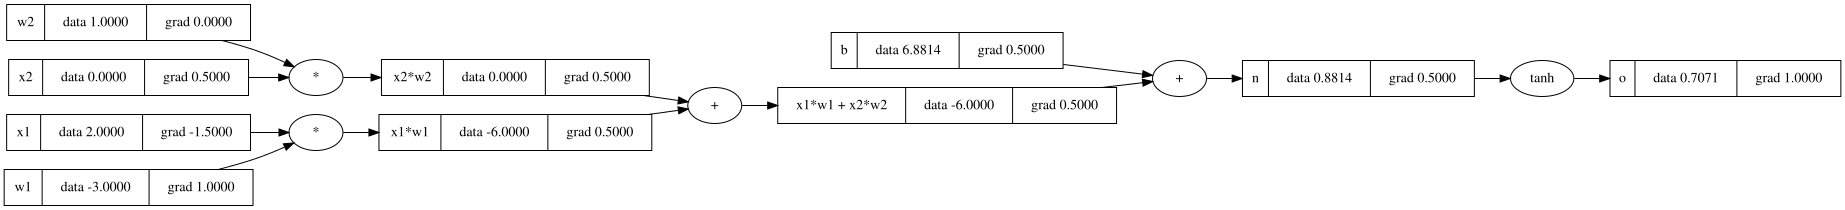

In [7]:
draw_dot(o)

In [8]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

e=(2*n).exp()
o=(e-1)/(e+1)

o.label = 'o'

In [9]:
o.backward()

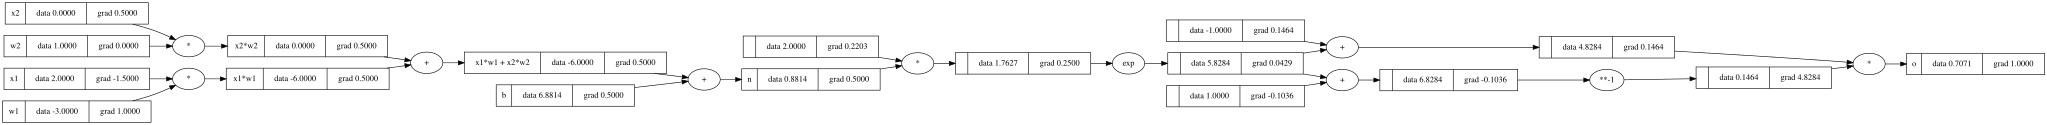

In [10]:
draw_dot(o)

In [18]:
# Using PyTorch
x1=torch.Tensor([2.0]); x1.requires_grad=True
x2=torch.Tensor([0.0]); x2.requires_grad=True

w1=torch.Tensor([-3.0]); w1.requires_grad=True
w2=torch.Tensor([1.0]); w2.requires_grad=True

b=torch.Tensor([6.8813735870195432]); b.requires_grad=True

n=x1*w1+x2*w2+b
o=torch.tanh(n)
print(o.data.item())
o.backward()

print("x2", x2.grad.item())
print("w2", w2.grad.item())
print("x1", x1.grad.item())
print("w1", w1.grad.item())

0.7071067094802856
x2 0.5000001192092896
w2 0.0
x1 -1.5000003576278687
w1 1.000000238418579


In [194]:
class Neuron:
    def __init__(self,nin):
        self.w=[Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b=Value(random.uniform(-1,1))

    def __call__(self,x):
        act=sum([wi*xi for wi,xi in zip(self.w,x)],self.b)
        out=act.tanh()
        return out

    def parameters(self):
        return self.w+[self.b]

class Layer:
    def __init__(self,nin,nout):
        self.neurons=[Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs=[n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self,nin,nouts):
        sz=[nin]+nouts
        self.layers=[Layer(sz[i],sz[i+1]) for i in range(len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x=layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [215]:
n=MLP(3,[4,4,1])

len(n.parameters())

41

In [216]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]

ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred=[n(x) for x in xs]
ypred


[Value(data= 0.0852),
 Value(data= 0.4475),
 Value(data= 0.7815),
 Value(data= 0.5804)]

In [320]:
for e in range(20):

    #forward pass
    ypred=[n(x) for x in xs]
    loss=sum((yp-ygt)**2 for ygt,yp in zip(ys,ypred))

    #backward pass
    loss.backward()

    #update
    for p in n.parameters():
        p.data+=-0.05*p.grad
        p.grad=0
    print(f"epoch: {e}, loss: {loss.data}")

epoch: 0, loss: 0.0002790596289033993
epoch: 1, loss: 0.00027891498247460255
epoch: 2, loss: 0.00027877048222232735
epoch: 3, loss: 0.00027862612792721106
epoch: 4, loss: 0.0002784819193703536
epoch: 5, loss: 0.00027833785633327374
epoch: 6, loss: 0.0002781939385979302
epoch: 7, loss: 0.00027805016594671124
epoch: 8, loss: 0.0002779065381624438
epoch: 9, loss: 0.00027776305502837394
epoch: 10, loss: 0.0002776197163281935
epoch: 11, loss: 0.00027747652184601304
epoch: 12, loss: 0.0002773334713663681
epoch: 13, loss: 0.0002771905646742284
epoch: 14, loss: 0.00027704780155499305
epoch: 15, loss: 0.0002769051817944672
epoch: 16, loss: 0.00027676270517890014
epoch: 17, loss: 0.0002766203714949516
epoch: 18, loss: 0.00027647818052970656
epoch: 19, loss: 0.0002763361320706741


In [321]:
ypred

[Value(data= 0.9939),
 Value(data= -0.9928),
 Value(data= -0.9908),
 Value(data= 0.9899)]

In [104]:
x=[(0,0),(0,1),(1,0),(1,1)]
y=[0,1,1,0]

# Input → Hidden

w11 = 22
w21 = 34
b1  = -6.5

w12 = 3
w22 = -14
b2  = 1.5

# Hidden → Output

v1 = 1
v2 = -1
bo = -0.5

lr=1

In [105]:
def step(z):
    return int(z>0)

def sigmoid(z):
    return 1/(1+math.exp(-z))

def sigmoid_derivative(z):
    return z*(1-z)

loss_arr=[]

epochs=10000
for i in range(epochs):

    for j in range(len(x)):
        #forward pass
        x1,x2=x[j]
        h11=w11*x1+w21*x2+b1
        h12=w12*x1+w22*x2+b2

        o1=sigmoid(h11)
        o2=sigmoid(h12)

        h2=o1*v1+o2*v2+bo

        y_pred=sigmoid(h2)

        #loss
        loss = 0.5 * (y[j] - y_pred)**2
        if i%1000==0:
            loss_arr.append((i,loss))

        #back propogation
        delta_y_pred=y_pred-y[j]
        delta_h2=sigmoid_derivative(y_pred)
        delta_o1=v1
        delta_o2=v2
        delta_h11=sigmoid_derivative(o1)
        delta_h12=sigmoid_derivative(o2)
        delta_w11=x1
        delta_w21=x2
        delta_w12=x1
        delta_w22=x2

        #weight update
        w11=w11-lr*(delta_y_pred*delta_h2*delta_o1*delta_h11*delta_w11)
        w21=w21-lr*(delta_y_pred*delta_h2*delta_o1*delta_h11*delta_w21)
        w12=w12-lr*(delta_y_pred*delta_h2*delta_o2*delta_h12*delta_w12)
        w22=w22-lr*(delta_y_pred*delta_h2*delta_o2*delta_h12*delta_w22)

        v1 = v1 - lr * delta_y_pred * delta_h2 * o1
        v2 = v2 - lr * delta_y_pred * delta_h2 * o2


        #bias update
        bo=bo-lr*(delta_y_pred*delta_h2)
        b1=b1-lr*(delta_y_pred*delta_h2*delta_o1*delta_h11)
        b2=b2-lr*(delta_y_pred*delta_h2*delta_o2*delta_h12)
        print(f"x={x[j]}, actual={y[j]}, pred={y_pred}, loss={loss:.2f}, w11={w11:.2f}, w21={w21:.2f}, b1={b1:.2f}, w12={w12:.2f}, w22={w22:.2f}, b2={b2:.2f}")

x=(0, 0), actual=0, pred=0.21147233688563175, loss=0.02, w11=22.00, w21=34.00, b1=-6.50, w12=3.00, w22=-14.00, b2=1.51
x=(0, 1), actual=1, pred=0.6141237703456377, loss=0.07, w11=22.00, w21=34.00, b1=-6.50, w12=3.00, w22=-14.00, b2=1.51
x=(1, 0), actual=1, pred=0.40853740898366014, loss=0.17, w11=22.00, w21=34.00, b1=-6.50, w12=3.00, w22=-14.00, b2=1.50
x=(1, 1), actual=0, pred=0.7177522779073913, loss=0.26, w11=22.00, w21=34.00, b1=-6.50, w12=3.00, w22=-14.00, b2=1.50
x=(0, 0), actual=0, pred=0.23672043559384467, loss=0.03, w11=22.00, w21=34.00, b1=-6.50, w12=3.00, w22=-14.00, b2=1.51
x=(0, 1), actual=1, pred=0.6456005968380275, loss=0.06, w11=22.00, w21=34.00, b1=-6.50, w12=3.00, w22=-14.00, b2=1.51
x=(1, 0), actual=1, pred=0.46244927558970317, loss=0.14, w11=22.00, w21=34.00, b1=-6.50, w12=3.00, w22=-14.00, b2=1.51
x=(1, 1), actual=0, pred=0.7367478535726343, loss=0.27, w11=22.00, w21=34.00, b1=-6.50, w12=3.00, w22=-14.00, b2=1.51
x=(0, 0), actual=0, pred=0.2568136919668849, loss=0.

In [106]:
loss_arr

[(0, 0.022360274633935064),
 (0, 0.07445023230613308),
 (0, 0.17491399828588103),
 (0, 0.2575841662206245),
 (1000, 0.0005483312291072827),
 (1000, 0.1412594227609803),
 (1000, 0.0006822979634669929),
 (1000, 0.14323039184179553),
 (2000, 0.00022526018857142082),
 (2000, 0.1417602651785365),
 (2000, 0.0002799253490712553),
 (2000, 0.1425765721695841),
 (3000, 0.0001403488051097832),
 (3000, 0.14189988643277396),
 (3000, 0.00017133143605925394),
 (3000, 0.14239562941367828),
 (4000, 0.00010183787919814047),
 (4000, 0.14196325822292974),
 (4000, 0.00012220507378495987),
 (4000, 0.14231349379442518),
 (5000, 7.992057785596567e-05),
 (5000, 0.14199884278377306),
 (5000, 9.450637169468688e-05),
 (5000, 0.14226728483276913),
 (6000, 6.578130497331857e-05),
 (6000, 0.14202139940112962),
 (6000, 7.683267043471545e-05),
 (6000, 0.1422379195955883),
 (7000, 5.5903616599566805e-05),
 (7000, 0.14203686858485398),
 (7000, 6.462159586628285e-05),
 (7000, 0.1422177251259683),
 (8000, 4.86120692214671

In [108]:
j=1
x1,x2=x[j]
h11=w11*x1+w21*x2+b1
h12=w12*x1+w22*x2+b2

o1=sigmoid(h11)
o2=sigmoid(h12)

h2=o1*v1+o2*v2+bo

y_pred=sigmoid(h2)
print(x[j], f"y_pred={y_pred:.6f}, y={y[j]}")

(0, 1) y_pred=0.466984, y=1


In [64]:
import math

x = [(0,0), (0,1), (1,0), (1,1)]
y = [0, 1, 1, 0]

# Input → Hidden

w11 = -1
w21 = 4
b1  = 3.5

w12 = -2
w22 = 3
b2  = -1.5

# Hidden → Output

v1 = 1
v2 = -1
bo = -0.5

lr = 0.5


def sigmoid(z):
    return 1 / (1 + math.exp(-z))


def sigmoid_derivative(output):
    return output * (1 - output)


epochs = 10000

for epoch in range(epochs):

    total_loss = 0

    for j in range(len(x)):

        x1, x2 = x[j]

        # =========================
        # FORWARD PASS
        # =========================

        h11 = w11*x1 + w21*x2 + b1
        h12 = w12*x1 + w22*x2 + b2

        o1 = sigmoid(h11)
        o2 = sigmoid(h12)

        h2 = o1*v1 + o2*v2 + bo

        y_pred = sigmoid(h2)


        # =========================
        # LOSS
        # =========================

        loss = 0.5 * (y[j] - y_pred)**2
        total_loss += loss


        # =========================
        # BACKPROPAGATION
        # =========================

        # Output layer
        delta_y = (y_pred - y[j]) * sigmoid_derivative(y_pred)

        # Hidden layer
        delta_o1 = delta_y * v1 * sigmoid_derivative(o1)
        delta_o2 = delta_y * v2 * sigmoid_derivative(o2)


        # =========================
        # WEIGHT UPDATES
        # =========================

        # Hidden -> output
        v1 -= lr * delta_y * o1
        v2 -= lr * delta_y * o2

        bo -= lr * delta_y


        # Input -> hidden
        w11 -= lr * delta_o1 * x1
        w21 -= lr * delta_o1 * x2

        w12 -= lr * delta_o2 * x1
        w22 -= lr * delta_o2 * x2


        # Hidden biases
        b1 -= lr * delta_o1
        b2 -= lr * delta_o2


    if epoch % 1000 == 0:
        print("Epoch:", epoch, "Loss:", total_loss)

Epoch: 0 Loss: 0.5895796217591809
Epoch: 1000 Loss: 0.33017364038272723
Epoch: 2000 Loss: 0.00683540302754107
Epoch: 3000 Loss: 0.003107107674996843
Epoch: 4000 Loss: 0.001979314195465337
Epoch: 5000 Loss: 0.0014432003947785555
Epoch: 6000 Loss: 0.0011319648246802655
Epoch: 7000 Loss: 0.0009293704808073504
Epoch: 8000 Loss: 0.0007872982468741067
Epoch: 9000 Loss: 0.0006823067233823357


In [65]:
print("\nPredictions:")

for x1, x2 in x:

    h11 = w11*x1 + w21*x2 + b1
    h12 = w12*x1 + w22*x2 + b2

    o1 = sigmoid(h11)
    o2 = sigmoid(h12)

    h2 = o1*v1 + o2*v2 + bo

    y_pred = sigmoid(h2)

    print(
        (x1, x2),
        "->",
        y_pred,
        "->",
        int(y_pred >= 0.5)
    )


Predictions:
(0, 0) -> 0.017246445974446543 -> 0
(0, 1) -> 0.983879125987788 -> 1
(1, 0) -> 0.9799450609630371 -> 1
(1, 1) -> 0.015603028030304092 -> 0
